## Before You Begin

1. Open `lab01_azure_ai_foundry.ipynb` in Visual Studio Code.
2. Install and enable the suggested extensions:
   - Python (Microsoft)
   - Jupyter (Microsoft)
3. Wait for both extensions to finish installing.

> **Note:** If the notebook does not run, no kernel appears, or you encounter a Jupyter activation error:
>
> - Open the **Jupyter** extension.
> - Click the **▼** next to **Uninstall**.
> - Select **Install Specific Version...**
> - Install **Jupyter v2025.4.0**.
> - Reload VS Code and reopen the notebook.

## Configure the Kernel

1. Click **Select Kernel**.
2. Under **Kernel Source**, select **Python Environments...**
3. Choose **Python 3.12.1**.

You can now run the notebook.

> **Tip:** Keep the Azure AI Foundry project page open in Microsoft Edge for easy access during the lab. If multiple AI Foundry resources are available, confirm with the instructor which resource should be used. The resource and model deployed during the demonstration can be used unless instructed otherwise.

# Azure Al Foundry and Generative Al Foundations

# Introduction to Generative AI


## What is Generative AI?

Generative AI refers to models that learn patterns from large datasets and **produce new content**—text, code, images, audio, video, or structured JSON. Instead of just deciding *which class an input belongs to* (discriminative learning), a generative model learns a probability distribution over data and **samples** from it to create plausible outputs.

**Simple contrast**

* *Discriminative*: “Is this email spam?”
* *Generative*: “Draft a reply to this email in a friendly tone.”



## Why this matters now

1. **Transformers at scale**: The transformer architecture + massive pretraining datasets + accelerated hardware unlocked fluent, domain-spanning generation.
2. **Foundation models**: Broadly pretrained “generalists” that can be steered with prompts or lightly adapted to tasks.
3. **Accessible endpoints**: Cloud platforms (e.g., Azure AI Foundry) expose models via APIs and playgrounds, reducing setup friction.



## How modern LLMs work (practical view)

* **Tokens**: Inputs/outputs are processed as tokens (sub-word chunks).
* **Embeddings**: Each token is mapped to a dense vector capturing meaning and context.
* **Pretraining (self-supervised)**: The model learns to predict the next token, internalizing language, facts, styles, and patterns.
* **Instruction tuning & alignment**: Extra training phases teach the model to follow instructions and adhere to helpful/safe policies (e.g., RLHF/RLAIF).
* **Decoding (sampling)**: Parameters like **temperature**, **top-p**, and **max_output_tokens** control creativity, focus, and length—knobs you’ll use in the lab.



## What GenAI can do (relevant to this lab)

* **Text & Docs**: Summarize policies, draft emails, extract key fields, convert to structured JSON.
* **Code**: Generate scaffolds, explain errors, write tests.
* **Reasoning & Tools**: Follow multi-step instructions, call tools/APIs, and format outputs for downstream systems.
* **Multimodal**: Describe images, reason over UI screenshots, or produce captions (model-dependent).



## Common solution patterns (pick the lightest that works)

1. **Prompt-only**: No training—just strong system messages, constraints, and examples. Fastest to ship.
2. **RAG (Retrieval-Augmented Generation)**: Ground the model in *your* content (indexes/vector search) to reduce hallucinations and keep answers up-to-date.
3. **Lightweight adaptation**: Small parameter-efficient fine-tunes (e.g., LoRA) for tone/format/domain jargon when prompts alone aren’t enough.
4. **Tool use & agents**: Let models call functions/REST APIs, chain steps, and orchestrate workflows.

*Rule of thumb*: Start with **prompting + RAG**. Fine-tune only when you have a repeating gap prompts can’t fix.



## Risks & responsible use (what to watch during the lab)

* **Hallucinations**: Confident but wrong outputs. Mitigate by grounding (RAG), citing sources, and validating critical answers.
* **Bias & Safety**: Pretraining data can encode biases; use safety filters, policy prompts, and human review for sensitive tasks.
* **Privacy & Security**: Avoid sending secrets/PII; use least-privilege access and logging.
* **IP & Compliance**: Respect licensing and provide provenance where required.
* **Evaluation**: Track quality, safety, latency, and cost as first-class metrics.



## How we’ll control outputs in the lab

* **System message**: Sets role, tone, and format rules (e.g., “Return JSON only.”).
* **Temperature / top-p**: Lower = more deterministic; higher = more diverse/creative.
* **Max tokens**: Constrains response length; prevents runaways and reduces cost.
* **Schemas**: Ask for key-value JSON so downstream code can parse reliably.



## Key terms (quick glossary)

* **Prompt**: Instructions given to the model (system + user messages).
* **Context window**: Token budget for input + output; exceeding it truncates or fails.
* **Grounding**: Supplying authoritative context so answers cite or rely on it.
* **Hallucination**: Fabricated or non-grounded content presented as fact.
* **Response format**: Agreed structure (e.g., strict JSON) to integrate with tools.



## Mini self-check (use before moving on)

1. In one sentence, explain the difference between generative and discriminative models.
2. Which decoding parameter would you adjust to **reduce randomness**?
3. When should you consider **RAG** instead of fine-tuning?
4. Name one **risk** and one **mitigation** when using LLMs in production.

# Large Language Models (LLMs)


## What is an LLM?

A **Large Language Model (LLM)** is a neural network—typically a **transformer**—trained on massive text/code corpora to predict the next token. By repeatedly predicting tokens, LLMs can generate coherent text, follow instructions, write code, and structure outputs for downstream systems.

**Key idea:** If a model is good at next-token prediction, it can *compose* sentences, *reason* over context, and *format* information on demand.



## Mental model / anatomy

* **Tokenizer:** Splits text into subword **tokens** (e.g., “Internationalization” → `International`, `ization`). Tokenization affects cost, length limits, and formatting strategies.
* **Embeddings:** Tokens are mapped to dense vectors capturing meaning.
* **Transformer blocks:** Stacks of self-attention + feed-forward layers transform token representations into contextualized meaning.
* **Self-attention:** Each token can “attend” to others, enabling long-range dependencies and reasoning over prior text.
* **Positional encoding / RoPE:** Injects token order so the model understands sequence.
* **Context window:** The total token budget for prompt **plus** response. Exceeding it truncates or errors; efficient prompt design matters.



## Training lifecycle (practical view)

1. **Pretraining (self-supervised):** Learn general language patterns via next-token prediction. Produces a **foundation model**.
2. **Supervised fine-tuning (SFT) / Instruction tuning:** Teach the model to follow instructions with curated input→output examples.
3. **Alignment (RLHF/RLAIF):** Use human/AI preference signals to make responses helpful, safe, and compliant with policy.
4. **Safety layers:** Policy prompts, classifiers, blocklists, and post-filters to reduce unsafe or non-compliant content.



## Inference & decoding (how outputs are produced)

* **Greedy decoding:** Always pick the highest-probability token (deterministic, but can be bland).
* **Sampling controls:**

  * **Temperature:** Higher → more diverse/creative; lower → more deterministic.
  * **Top-p (nucleus):** Sample from the smallest set of tokens whose cumulative probability ≥ *p*.
  * **Top-k:** Sample from the top *k* tokens only.
  * **Penalties (frequency/presence):** Reduce repetition.
* **Length control:** `max_output_tokens` caps cost/verbosity and prevents runaways.
* **Format control:** System prompts, exemplars, and (when supported) `response_format` help enforce **strict JSON** or other schemas.



## What LLMs can do (relevant to this lab)

* **Generation:** Draft explanations, emails, summaries, plans.
* **Transformation:** Rewrite tone, translate, normalize, redact.
* **Extraction / Structuring:** Return **JSON** with fields; classify; map to enums.
* **Reasoning & Tools:** Stepwise reasoning; call **functions/APIs** (“tool use”) for retrieval, calculations, or database ops.
* **Few-shot learning:** Provide 1–3 examples in the prompt to steer style and format without training.



## Common solution patterns

1. **Prompt-only:** Carefully engineered system/user prompts; fast to ship.
2. **RAG (Retrieval-Augmented Generation):** Retrieve enterprise content and feed it as context to ground answers and reduce hallucinations.
3. **Parameter-efficient fine-tuning (e.g., LoRA):** Light adaptation when prompts + RAG can’t fix persistent gaps (tone, taxonomy).
4. **Agents / Tool orchestration:** Chain tool calls and multi-step plans for tasks like enrichment, validation, and workflow execution.

**Rule of thumb:** Start with **prompting + RAG**; fine-tune only when necessary.



## Constraints & failure modes

* **Hallucinations:** Fluent but wrong content. Mitigate with RAG, verification, and conservative decoding.
* **Context limits:** Long prompts can hit the window; summarize, chunk, and retrieve only what’s needed.
* **Tokenization quirks:** Weird splits affect counting and sometimes formatting. Measure in **tokens**, not characters.
* **Determinism vs creativity:** Temperature/top-p change reproducibility; set them intentionally for your use case.
* **Latency & rate limits:** Model size, output length, and concurrency affect responsiveness; watch quotas and batching.



## Cost & performance levers

* **Prompt tokens dominate cost** in RAG/long contexts—keep context lean and relevant.
* **Smaller/faster models** reduce latency and spend; use them when quality is “good enough.”
* **Caching** (prompt or response) can cut repeat costs.
* **Streaming** improves UX for longer answers without changing total tokens.



## Choosing an LLM (practical criteria)

* **Task fit:** Reasoning vs quick drafting; structured JSON vs open-ended writing.
* **Modalities:** Text-only vs multimodal (images/audio).
* **Quality vs cost:** Start small; step up only if needed.
* **Safety features:** Policy adherence, content filters, auditing.
* **Ecosystem fit:** SDKs, tool calling, eval tooling, deployment options in your platform.



## Operating LLMs in this lab

* Use the **system message** to define role, tone, and required output schema.
* Keep **temperature** low for procedural tasks; raise it for brainstorming.
* Set **max_output_tokens** conservatively, then raise if truncation is observed.
* When you need reliable structure, **ask for strict JSON** and validate client-side.
* For knowledge tasks, prefer **RAG** over hoping the model “remembers” facts.



## Quick glossary

* **Token:** Subword unit used by the model.
* **Embedding:** Vector representation of a token/text span.
* **Context window:** Max tokens prompt + output can occupy.
* **System message:** High-level behavioral contract for the model.
* **Hallucination:** Confident, non-grounded output.
* **Tool/function call:** Model emits a schema to trigger code or APIs.



## Mini self-check

1. What does **temperature** control, and when would you set it near 0?
2. Why is **RAG** usually preferred over fine-tuning for enterprise Q&A?
3. What is the **context window**, and why does it matter for cost/latency?
4. Name one mitigation for **hallucinations**.



## Bridge to the hands-on

You’ll now deploy a chat-capable model, test decoding settings in the **Playground**, and call the endpoint via SDK/REST while enforcing JSON output and measuring the quality–cost–latency trade-offs.

**Navigate to *AI Foundry Portal* (`https://ai.azure.com/`) and find the project created for you.**

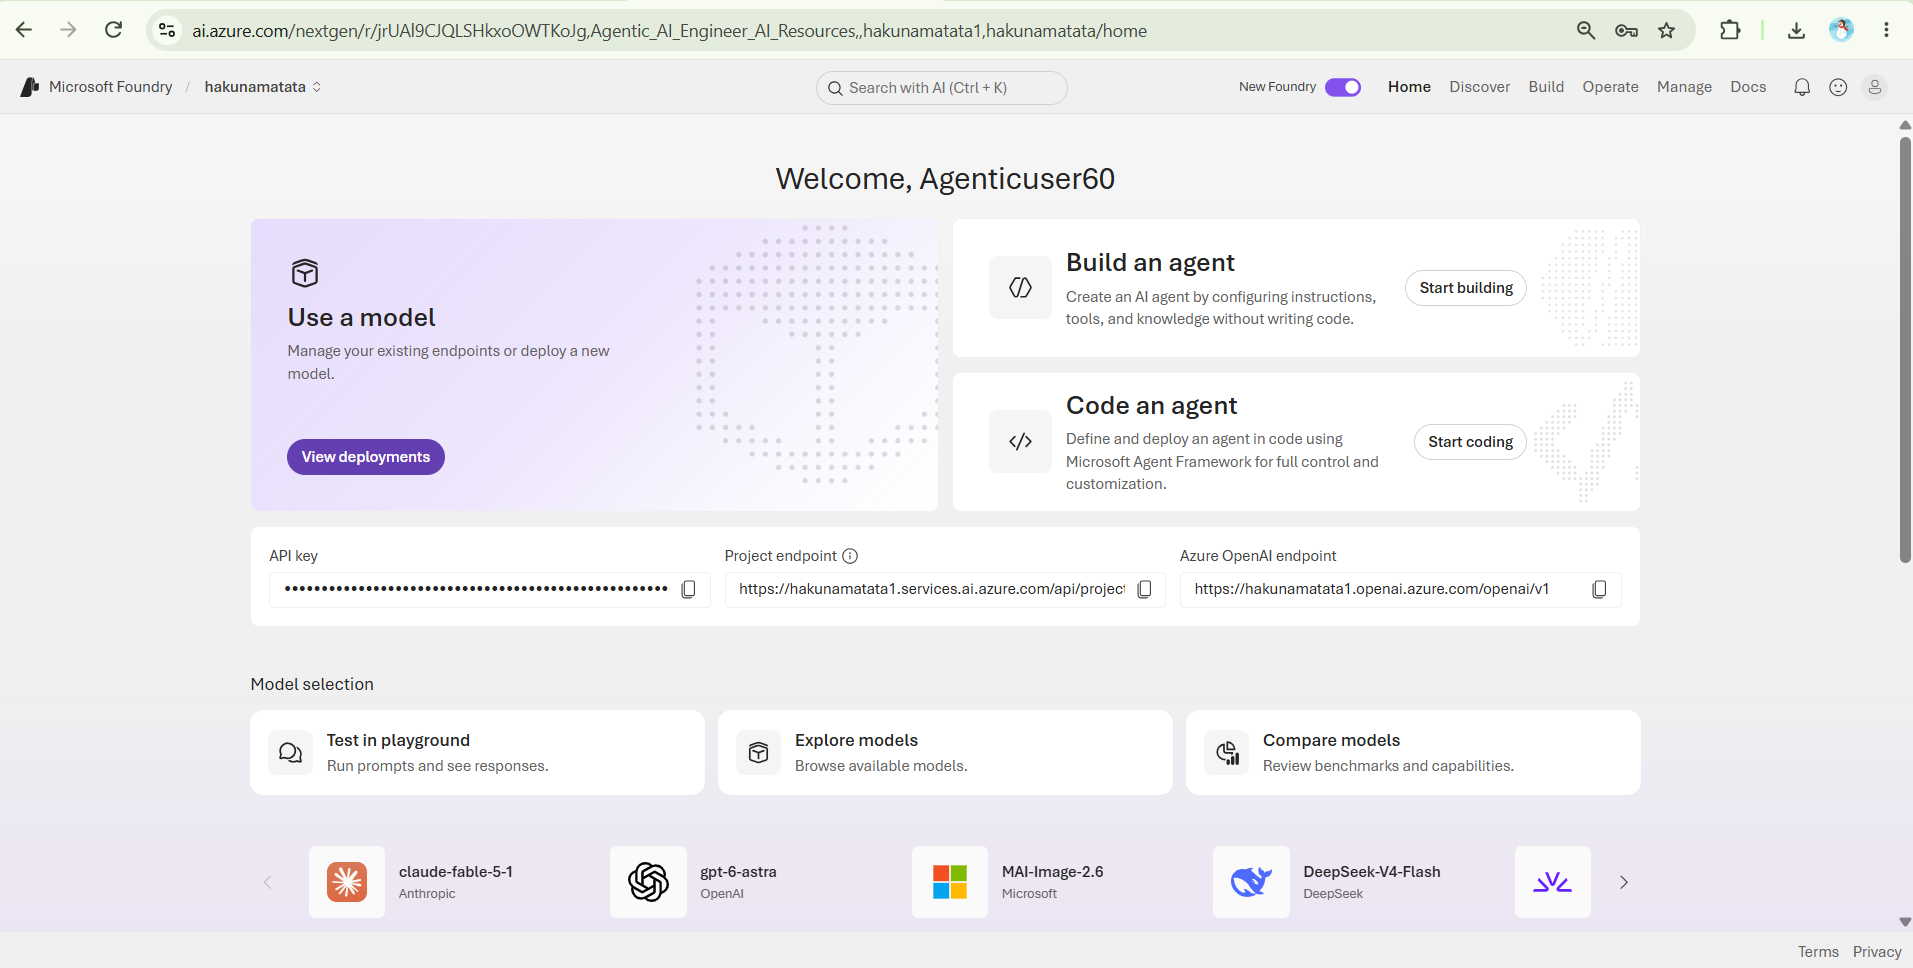


## 1) Page Context

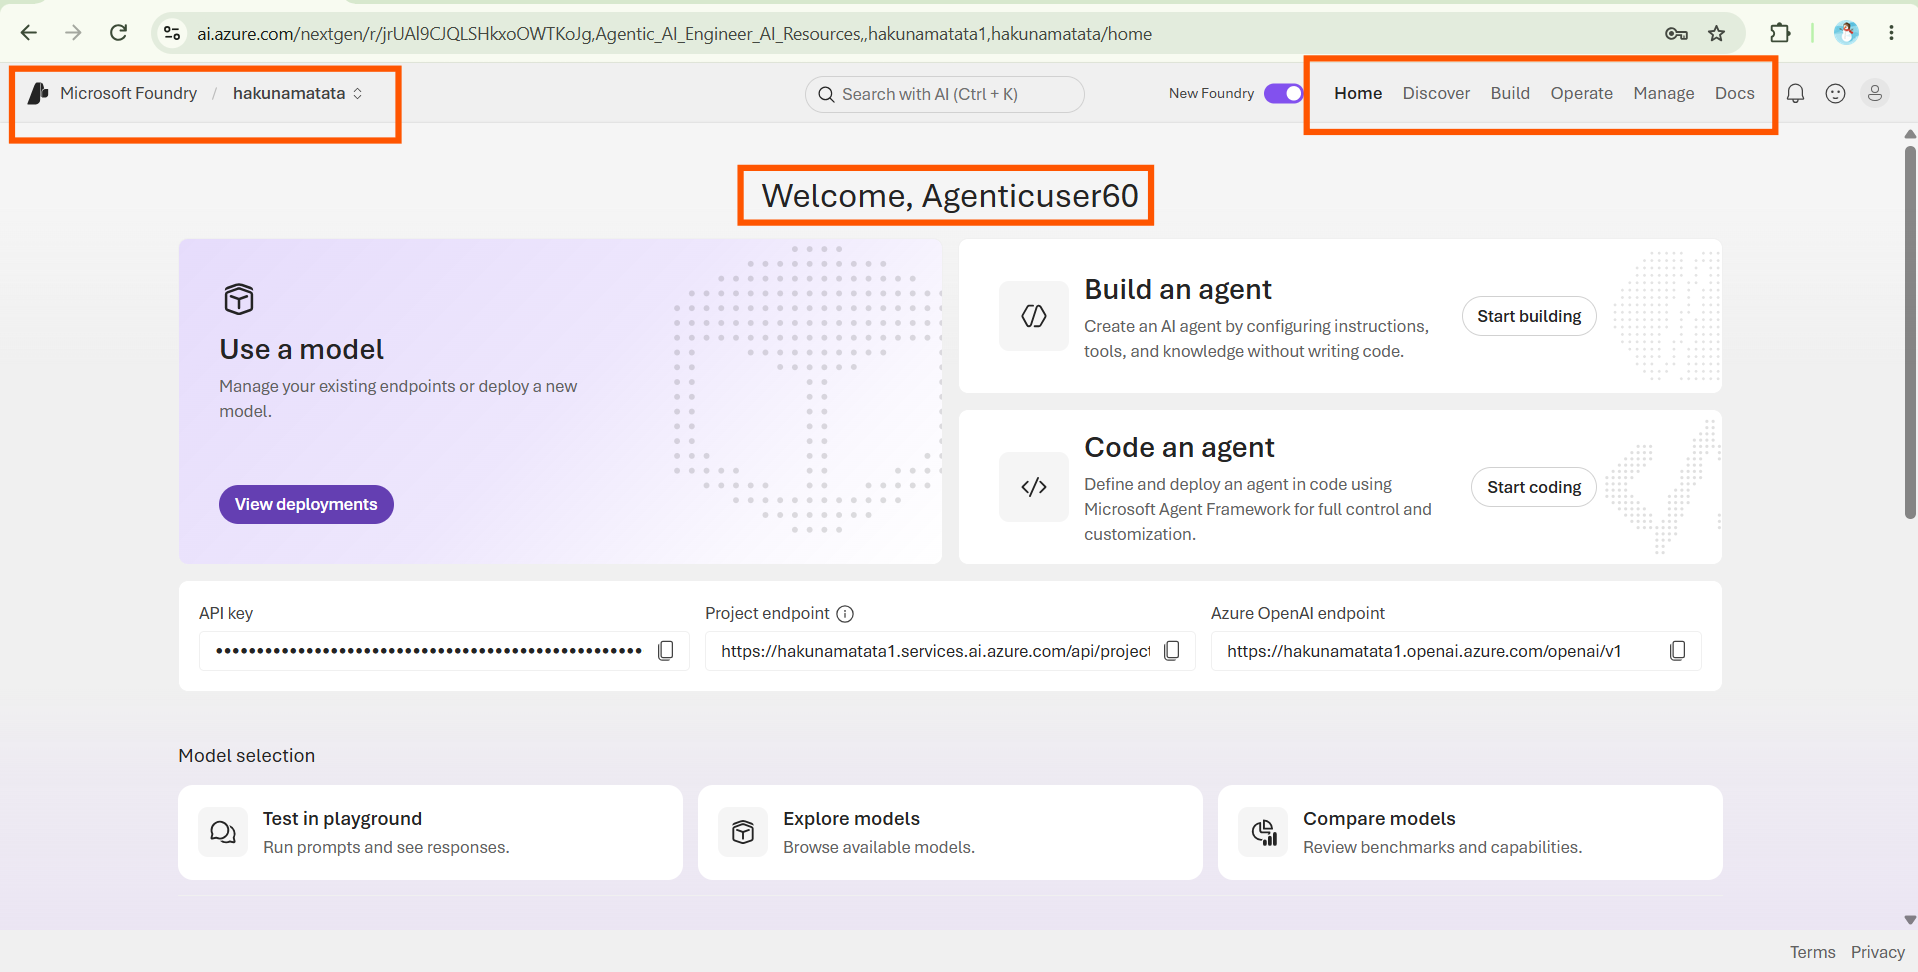


- **Header (top-left): Microsoft Foundry → hakunamatata**: Shows that you're currently working inside the **hakunamatata** Azure AI Foundry project.

- **Top-center: Search with AI (Ctrl + K)**: Allows you to quickly search resources, settings, models, and tools across Foundry.

- **Top-right: Home**: Displays the project's main dashboard, resources, endpoints, and quick-start options.

- **Top-right: Discover**: Lets you explore available AI models, examples, and capabilities.

- **Top-right: Build**: Used to create, configure, and deploy AI applications and agents.

- **Top-right: Operate**: Used to monitor deployments, review usage, and troubleshoot running solutions.

- **Top-right: Manage**: Used to manage project settings, permissions, connections, and resources.

- **Top-right: Docs**: Provides access to Microsoft documentation, tutorials, and learning materials.

- **Main heading: Welcome, Agenticuser60**: Displays the currently signed-in user account.

## 2) Main project cards

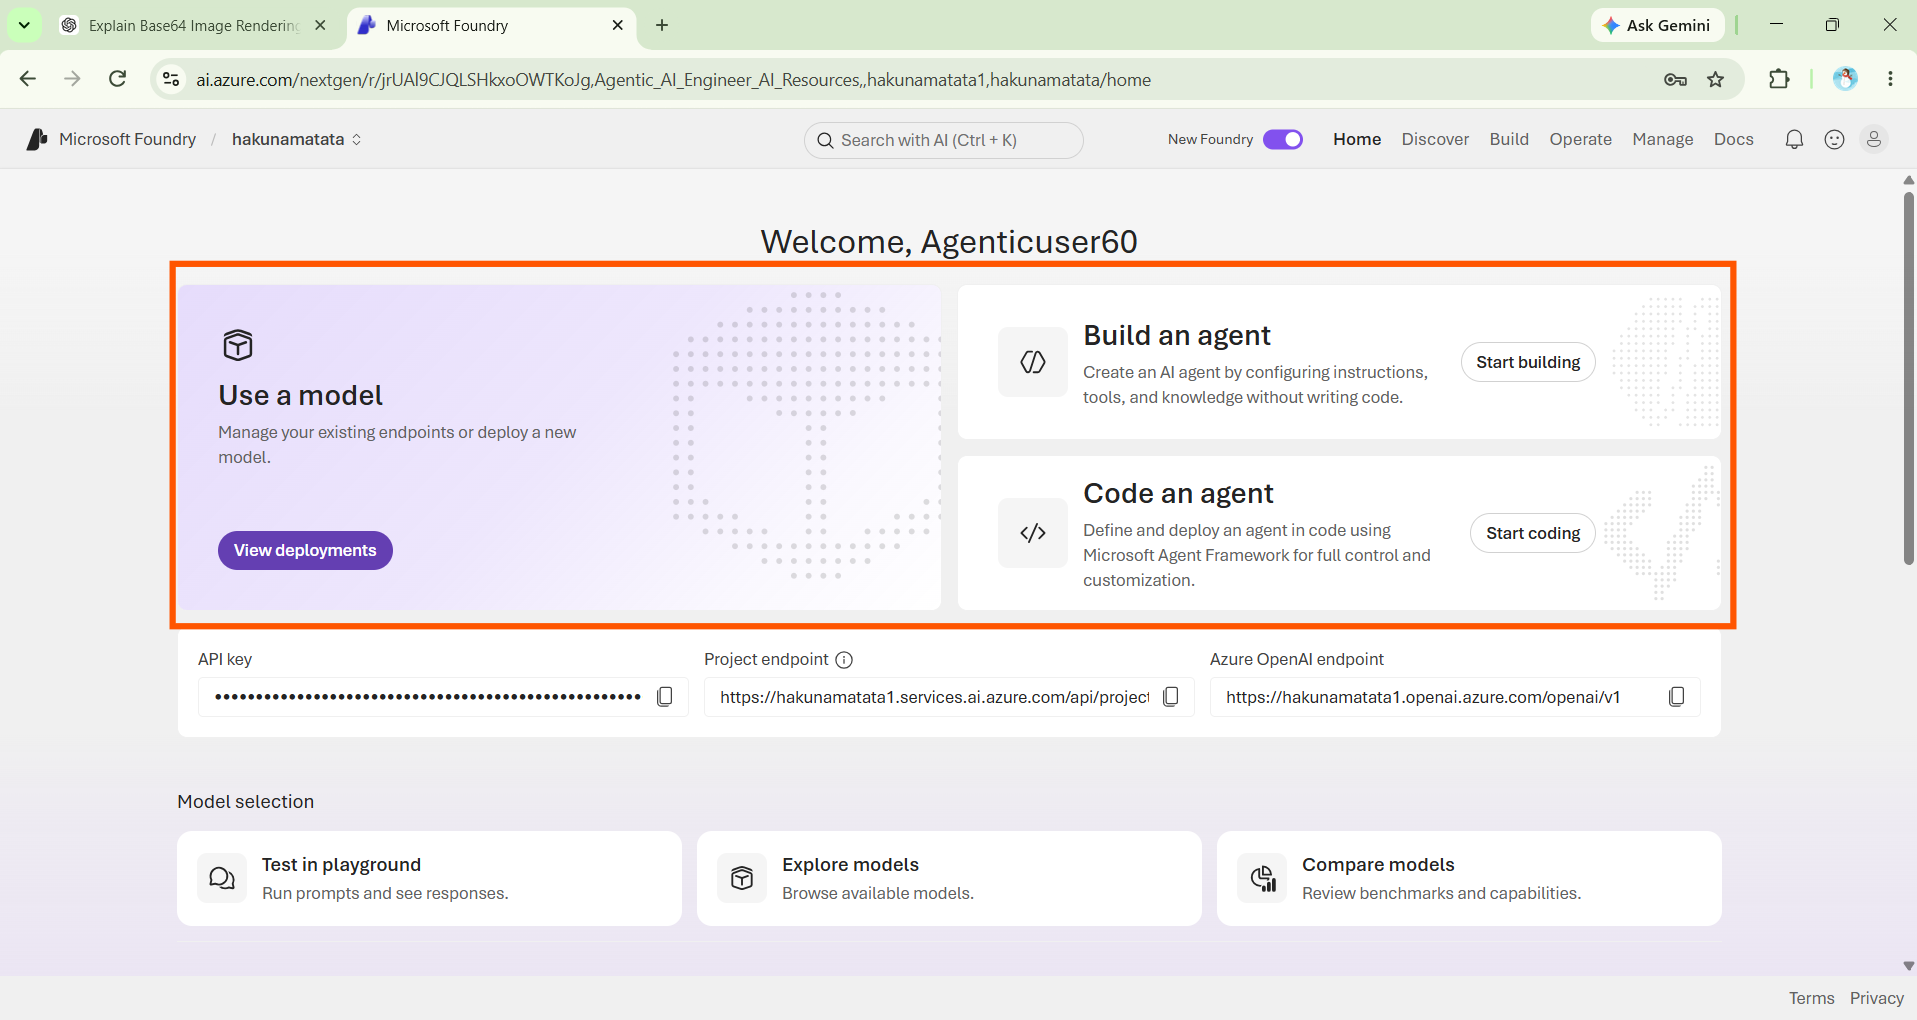

### **Use a model**

* Located on the **left**.
* Description: **Manage your existing endpoints or deploy a new model.**
* **View deployments** button → opens the available model deployments.

### **Build an agent**

* Located on the **top-right**.
* Description: **Create an AI agent by configuring instructions, tools, and knowledge without writing code.**
* **Start building** button → starts the agent-building workflow.

### **Code an agent**

* Located below **Build an agent**.
* Description: **Define and deploy an agent in code using Microsoft Agent Framework for full control and customization.**
* **Start coding** button → starts the coding workflow.

## 3) Endpoints & API key

Below the main cards, you can see three fields:

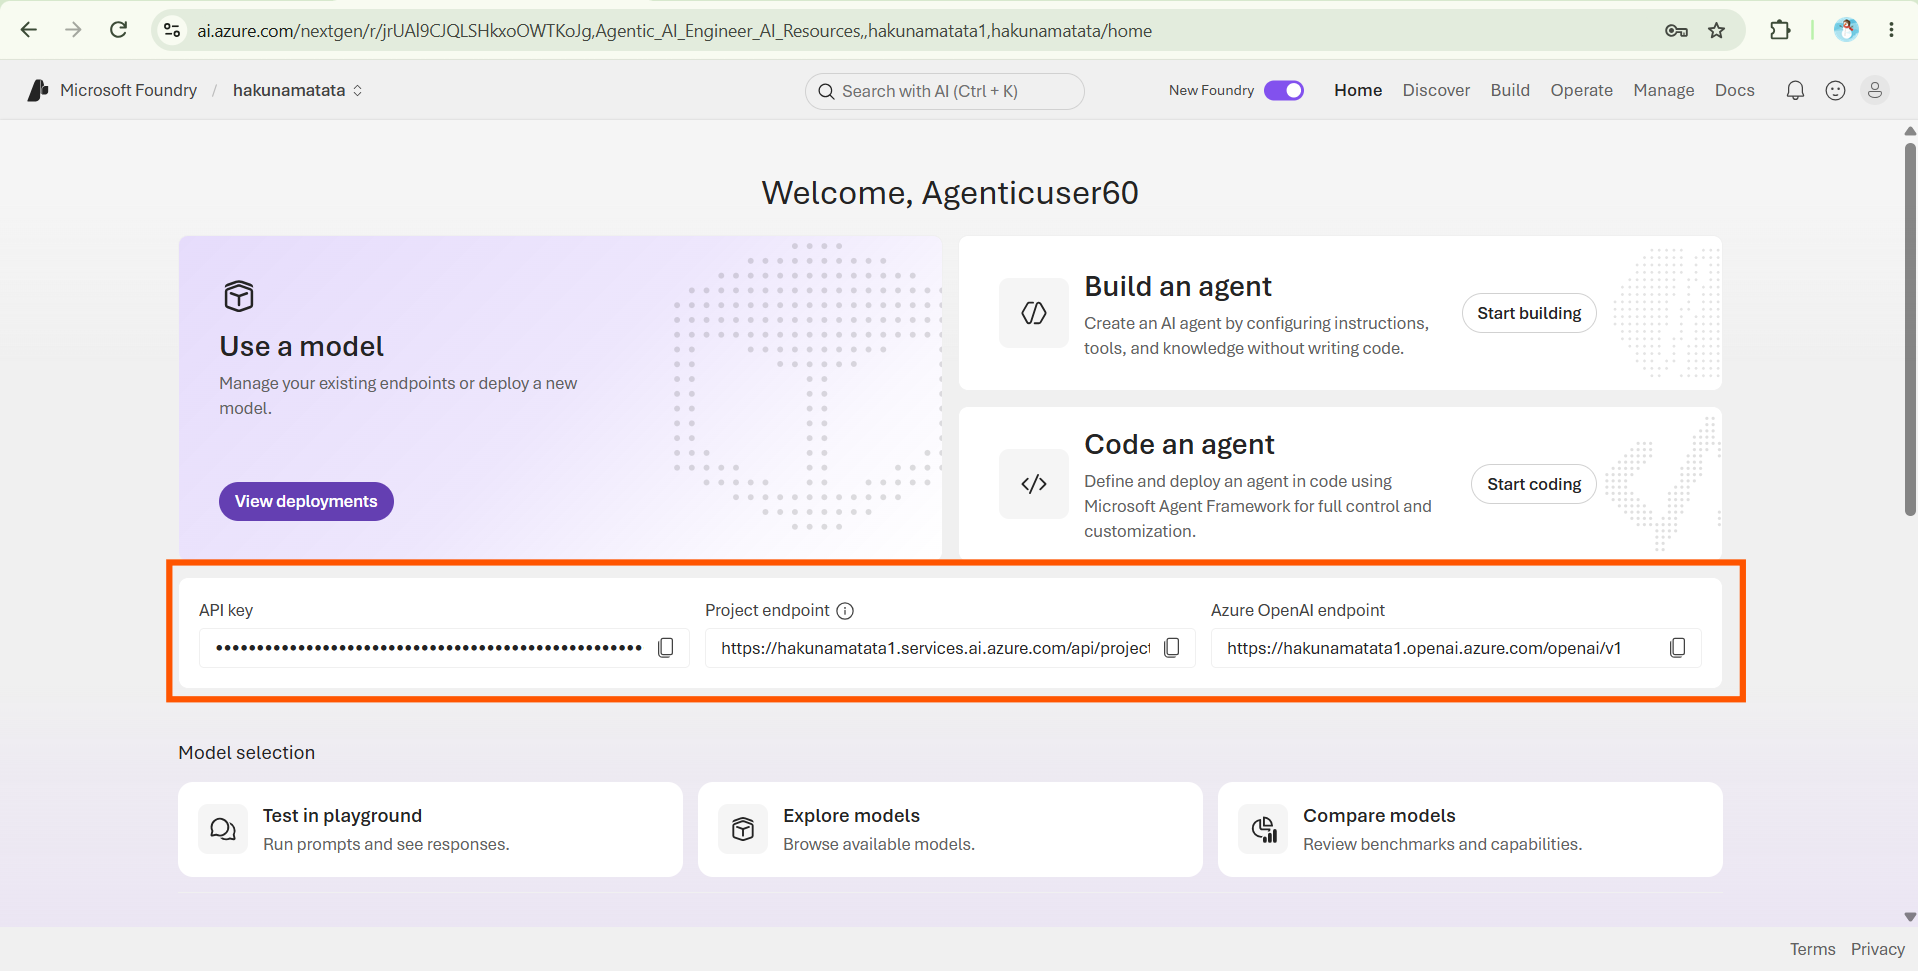

* **API key**

  * The key is masked.
  * **Copy icon** is available on the right.
  * Keep the API key private.

* **Project endpoint**

  * Shows the Azure AI Foundry project endpoint.
  * **Copy icon** is available.
  * This is the endpoint used when connecting to the project through SDK/API code.

* **Azure OpenAI endpoint**

  * Shows the Azure OpenAI endpoint.
  * **Copy icon** is available.
  * Used when working directly with Azure OpenAI APIs.

**Use in lab:** Copy the **API key** and the required **project endpoint** when the lab asks you to configure your SDK/API connection.

## 4) Model selection

Below the endpoint section, there is a **Model selection** area containing three cards:

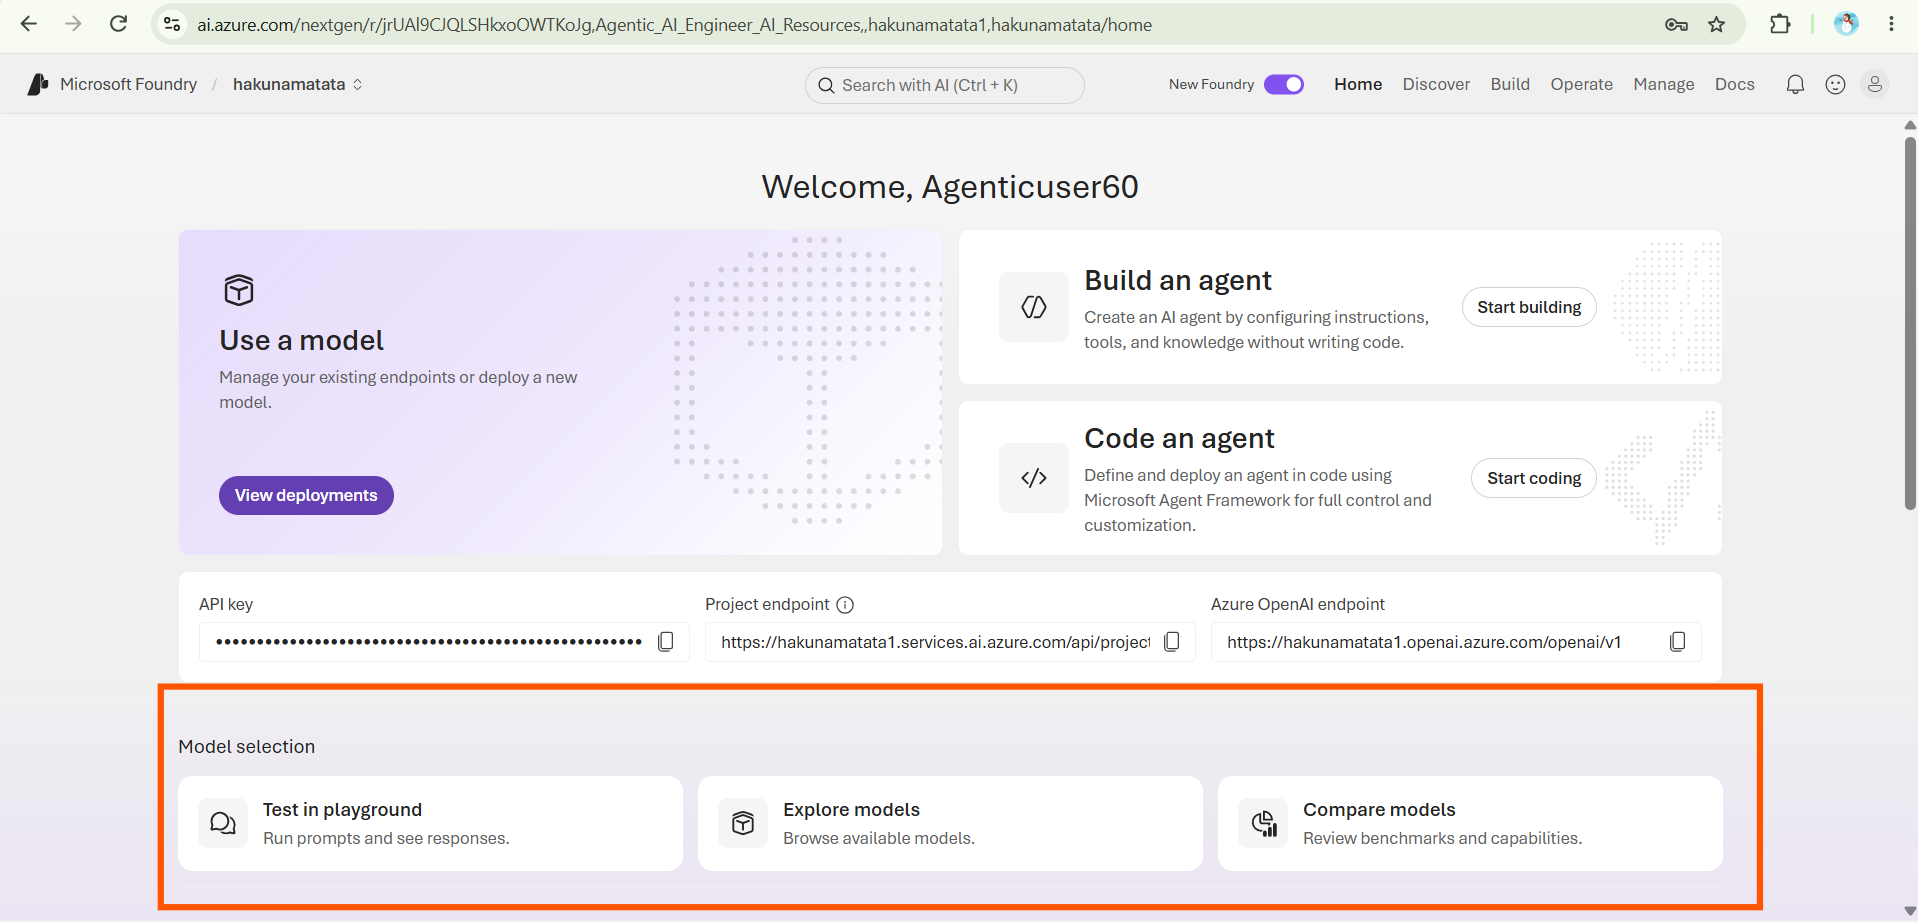


### **Test in playground**

* **Run prompts and see responses.**
* Used to interactively test models without writing code.

### **Explore models**

* **Browse available models.**
* Used to explore the models available in the project.

### **Compare models**

* **Review benchmarks and capabilities.**
* Used to compare available models based on their capabilities and performance information.

## 5) Available models

At the bottom of the page, the portal displays available models, including examples such as:

* **claude-fable-5-1** — Anthropic
* **gpt-6-astra** — OpenAI
* **MAI-Image-2.6** — Microsoft
* **DeepSeek-V4-Flash** — DeepSeek

There is also a **left/right navigation control** to view additional models

**Scroll down a little further** and you can see the following sections:

## 6) Recent work

The **Recent work** section has three filters:

**All | Agents | Models**

It shows your recently accessed models/projects in a table with:

| Name                    | Version             | Type  | Last viewed          | Endpoint      |
| ----------------------- | ------------------- | ----- | -------------------- | ------------- |
| **gpt-5.4-mini**        | gpt-5.4-mini        | Model | 9/24/26, 12:00:46 AM | View endpoint |
| **Phi-4-mini-instruct** | Phi-4-mini-instruct | Model | 9/23/26, 11:54:26 PM | View endpoint |

At the bottom, it shows **1-2 of 2**, with **Prev / Next** navigation.

## 7) Learning and resources

Further down, there is a **Learning and resources** section with three options:

### **Docs**

Explore the detailed Microsoft Foundry documentation.

### **GitHub**

Get the latest SDK updates and code samples on GitHub.

### **Discord**

Have questions? Join and connect with the Microsoft Foundry Discord community.

## Explore the Model Catalog

### Open Model Catalog

1. On the **Project Overview** page, under **Model selection**, you will see **Test in playground**, **Explore models**, and **Compare models**.
2. Click **Explore models**.
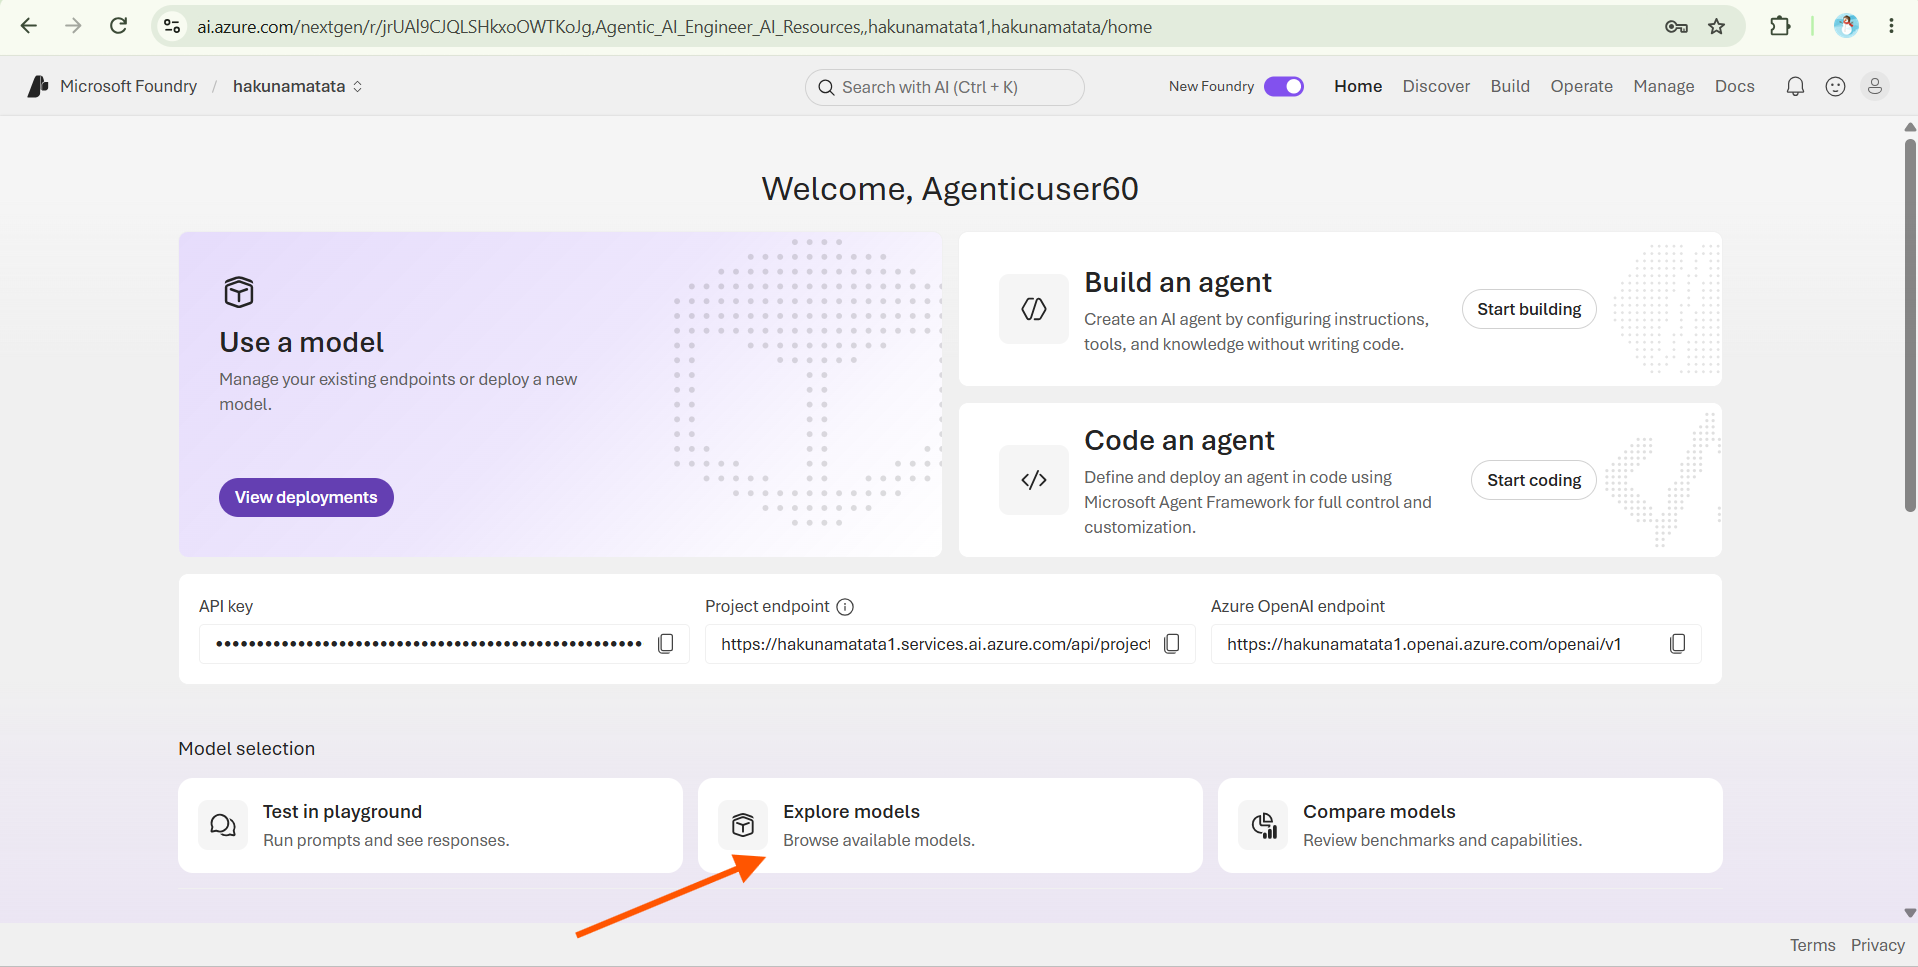

3. This opens the **Models** catalog, where you can browse the available models.


## What you’re looking at (screen anatomy)

### **Models catalog**

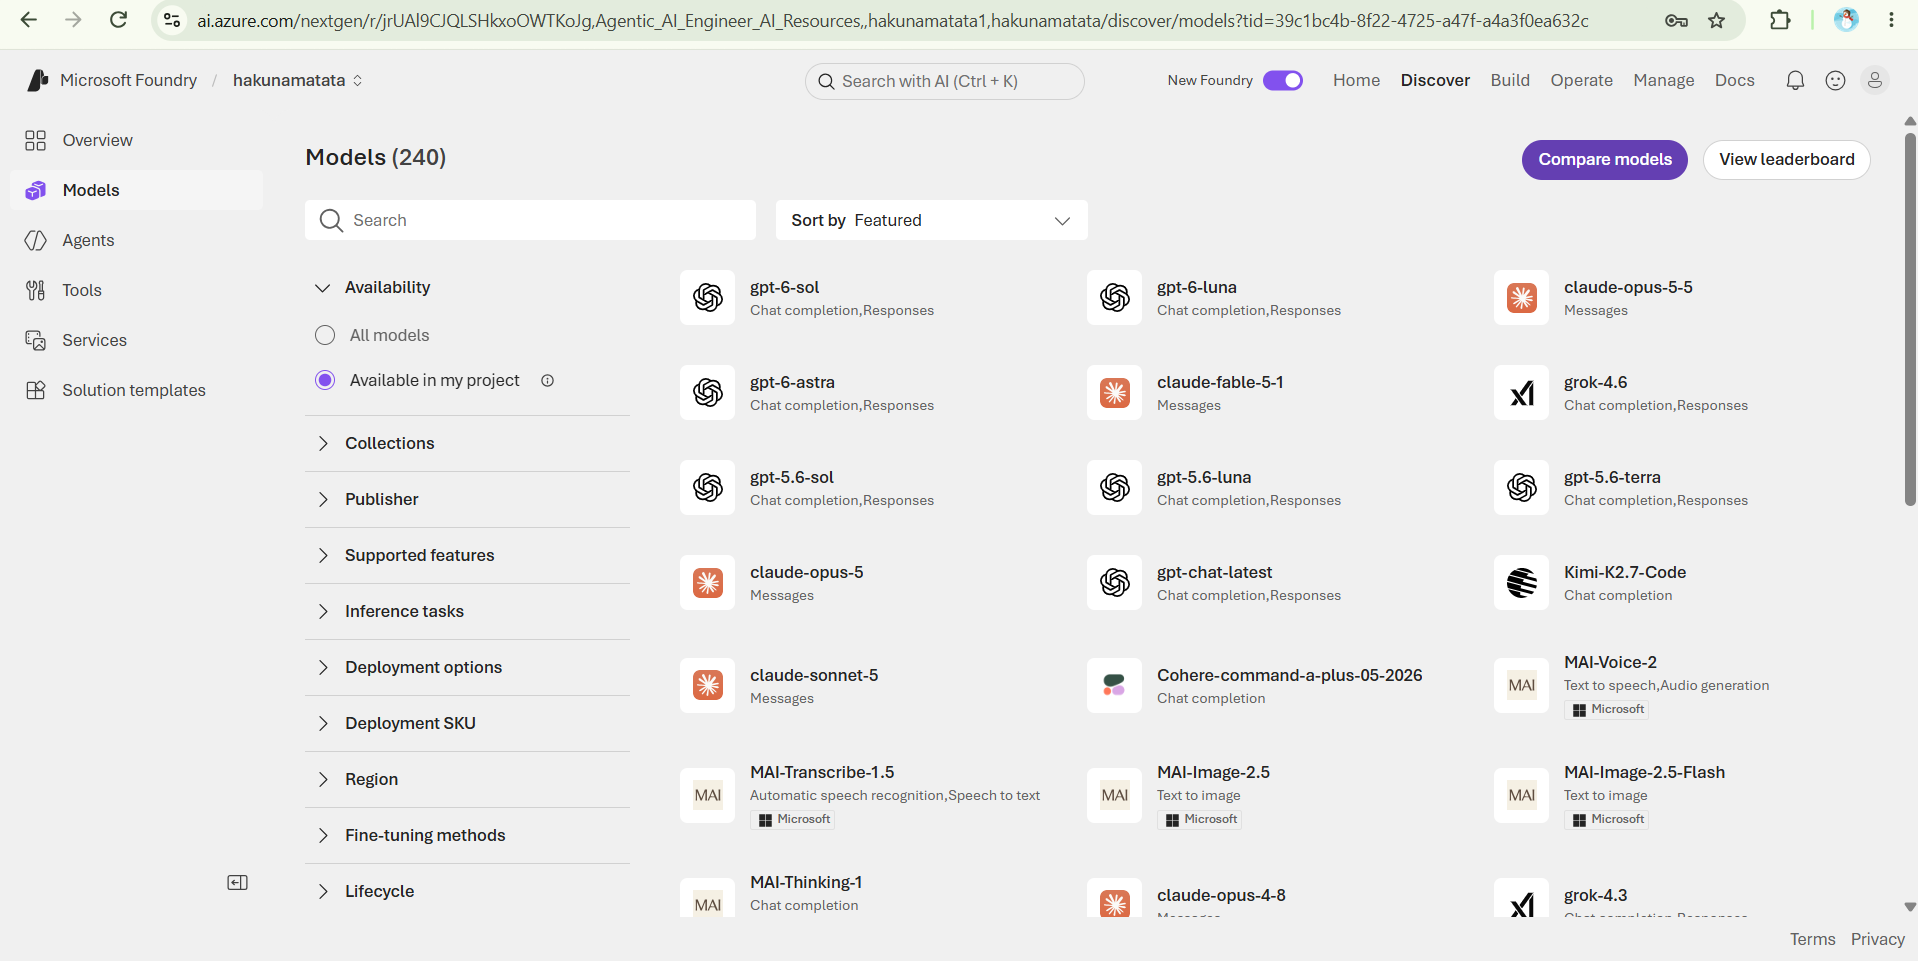


At the top of the page, you can see:

* **Models (239)** → shows the number of models currently listed in the catalog.
* **Search** → search for a specific model by name.
* **Sort by** → sort the available models, currently shown as **Featured**.
* **Compare models** → select models and compare their capabilities and performance.
* **View leaderboard** → view model performance metrics across different categories.

### **Availability**

The left-side filter contains:

* **All models** → displays all models available in the catalog.
* **Available in my project** → displays models currently available for your project.

### **Filters**

The left blade also provides filters to narrow down the model catalog:

* **Collections** → filter models by collection.
* **Publisher** → filter by model provider/publisher.
* **Supported features** → filter according to supported features.
* **Inference tasks** → filter based on the type of task the model supports.
* **Deployment options** → filter based on available deployment methods.
* **Deployment SKU** → filter based on deployment SKU.
* **Region** → filter models based on supported regions.
* **Fine-tuning methods** → filter models based on fine-tuning support.
* **Lifecycle** → filter based on model lifecycle status.
* **Domain** → filter by supported domain.
* **Industry** → filter by industry.

### **Model listings**

The main area displays individual model entries.

Examples visible in the current catalog include:

* **gpt-6-sol**
* **gpt-6-luna**
* **gpt-6-astra**
* **gpt-5.6-sol**
* **gpt-5.6-luna**
* **claude-fable-5-1**
* **claude-opus-5-5**
* **claude-sonnet-5**
* **grok-4.6**
* **Kimi-K2.7-Code**
* **MAI-Voice-2**
* **MAI-Image-2.5**
* **DeepSeek-V4-Pro**
* **DeepSeek-V4-Flash**

Each model entry shows the **model name**, **provider**, and supported task types such as **Chat completion, Responses, Messages, Text to image,** or **Speech to text**.

---

# Compare Models

Click **Compare models** at the top-right of the Model Catalog.
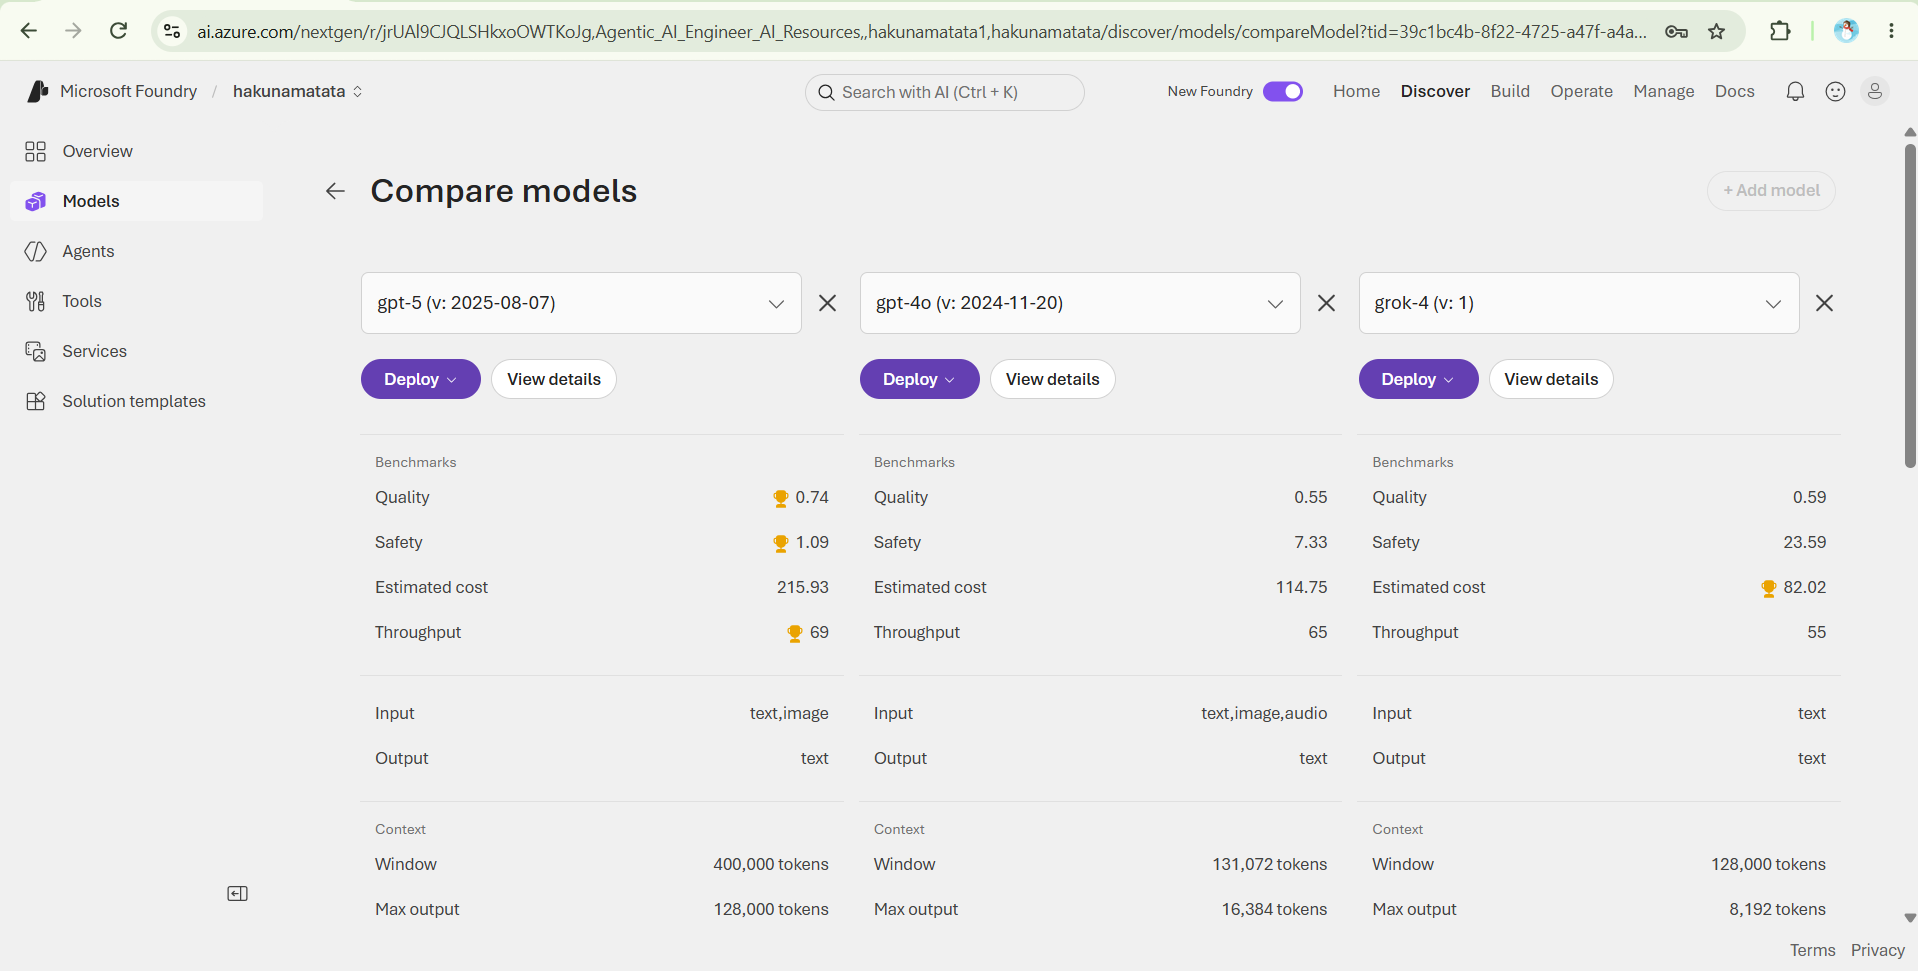


The comparison page allows you to view multiple models side-by-side.

For example, the comparison screen displays:

* **Model name and version**
* **Deploy** option
* **View details**
* **Quality**
* **Safety**
* **Estimated cost**
* **Throughput**
* **Input types**
* **Output types**
* **Context window**
* **Maximum output**
* **Training date**

You can use **+ Add model** to add another model to the comparison.

This is useful when you want to compare models based on the requirements of your application before deploying one.

---

# Model Leaderboard

Come back to Model Catalog and now click **View leaderboard**.

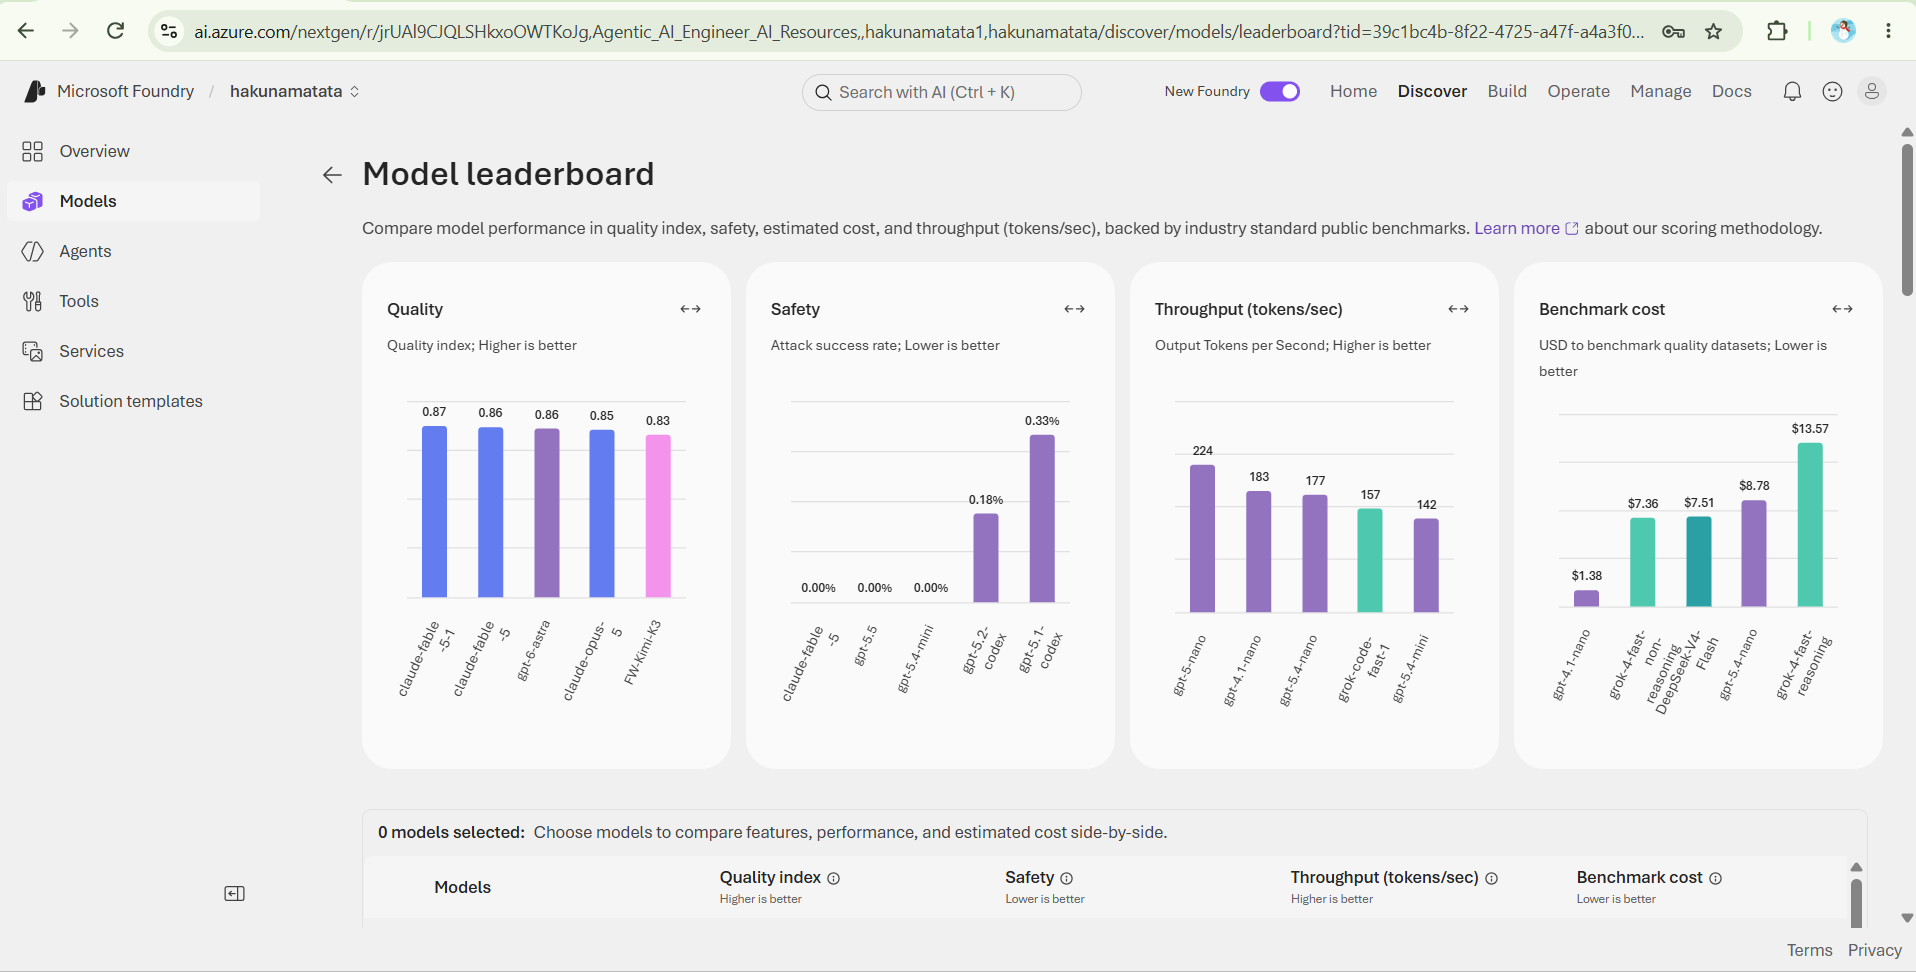


The **Model leaderboard** provides benchmark-based comparisons across four areas:

### **Quality**

Measures the model's quality index.

### **Safety**

Shows the measured attack success rate. **Lower is better** according to the portal.

### **Throughput (tokens/sec)**

Shows the number of output tokens generated per second. **Higher is better** for throughput.

### **Benchmark cost**

Shows benchmark cost for the evaluated datasets. **Lower is better** for cost.

Below the charts, you can select individual models and compare their:

* **Quality index**
* **Safety**
* **Throughput**
* **Benchmark cost**

**Tip:** Leaderboard results are benchmark measurements. For your own application, validate the models using your actual prompts and requirements in the Playground.

---

# Model Selection Workflow

1. **Start with Search and Filters**

   Search for a specific model or use filters such as **Publisher, Supported features, Inference tasks, Region,** and **Deployment options**.

2. **Check the model details**

   Open a model to review its supported capabilities, deployment information, and other specifications.

3. **Compare candidates**

   Use **Compare models** when you want to examine multiple models side-by-side.

4. **Check the leaderboard**

   Use **View leaderboard** to review benchmark measurements for **Quality, Safety, Throughput,** and **Benchmark cost**.

5. **Deploy the model**

   Once you've identified a model suitable for your use case, use the **Deploy** option from the model details or comparison page.

---

# Explore Foundation Models — Notable Families

The current catalog contains models from multiple providers. Some examples visible in the catalog include:

## OpenAI

Examples include **GPT-6** and **GPT-5.6** model variants.

* General-purpose language models.
* Support capabilities such as **Chat completion** and **Responses**.
* Suitable for applications such as assistants, coding, reasoning, and structured interactions.

## Anthropic

Examples include **Claude** model variants such as **Claude Fable**, **Claude Opus**, and **Claude Sonnet**.

* General-purpose language models.
* Useful for conversational, analytical, and long-context workloads.
* Capabilities depend on the specific model and version.

## Microsoft

Examples include **MAI-Voice-2**, **MAI-Image-2.5**, **MAI-Image-2.5-Flash**, and **MAI-Thinking-1**.

* Covers different workloads including text, image, speech, and reasoning.
* The supported input/output types depend on the individual model.

## DeepSeek

Examples include **DeepSeek-V4-Pro** and **DeepSeek-V4-Flash**.

* Language models available for conversational and related workloads.
* Check the individual model page for supported capabilities and deployment options.

## xAI

Examples include **Grok-4.6** and **Grok-4.3**.

* General-purpose language models.
* The catalog displays supported capabilities such as **Chat completion** and **Responses**.

## Kimi

Examples include **Kimi-K2.7-Code** and **Kimi-K2.6**.

* Includes models focused on language and coding workloads.
* Check the individual model details for supported features.

## Cohere

Examples include **Cohere Command** models.

* Designed for language and enterprise-oriented workloads.
* Check the specific model page for supported capabilities.

---

# Picking a Model

When selecting a model, consider:

* **Task fit:** Choose a model that supports your required task, such as chat, coding, image generation, or speech.
* **Quality:** Check benchmark results and test the model with your own prompts.
* **Latency and throughput:** Consider throughput when response speed matters.
* **Cost:** Compare estimated or benchmark costs when working under a budget.
* **Context window:** Check the supported context size for applications involving large amounts of text.
* **Region:** Make sure the model is available in the region required by your project.
* **Deployment options:** Check which deployment options and SKUs are available.
* **Features:** Verify support for capabilities such as Responses, Chat completion, tool calling, structured outputs, or multimodal input where required.

**Best practice:** Use the **Model Catalog → Model Details → Compare Models → Leaderboard → Playground** flow to evaluate a model before using it in your application.

## Use the Deployed Model

Use the **deployed `gpt-5.4-mini` model** for the upcoming hands-on exercises and API/code execution.

> **Note:** Please use the existing deployment, as we already have a deployed model available. This avoids the need to create additional deployments and helps prevent unnecessary resource consumption during the hands-on exercises.

# Chat Playground — What Each Area Does

## Open the Chat Playground

1. Come back to the **project overview page**.
2. Under **Model selection**, click **View deployments**.
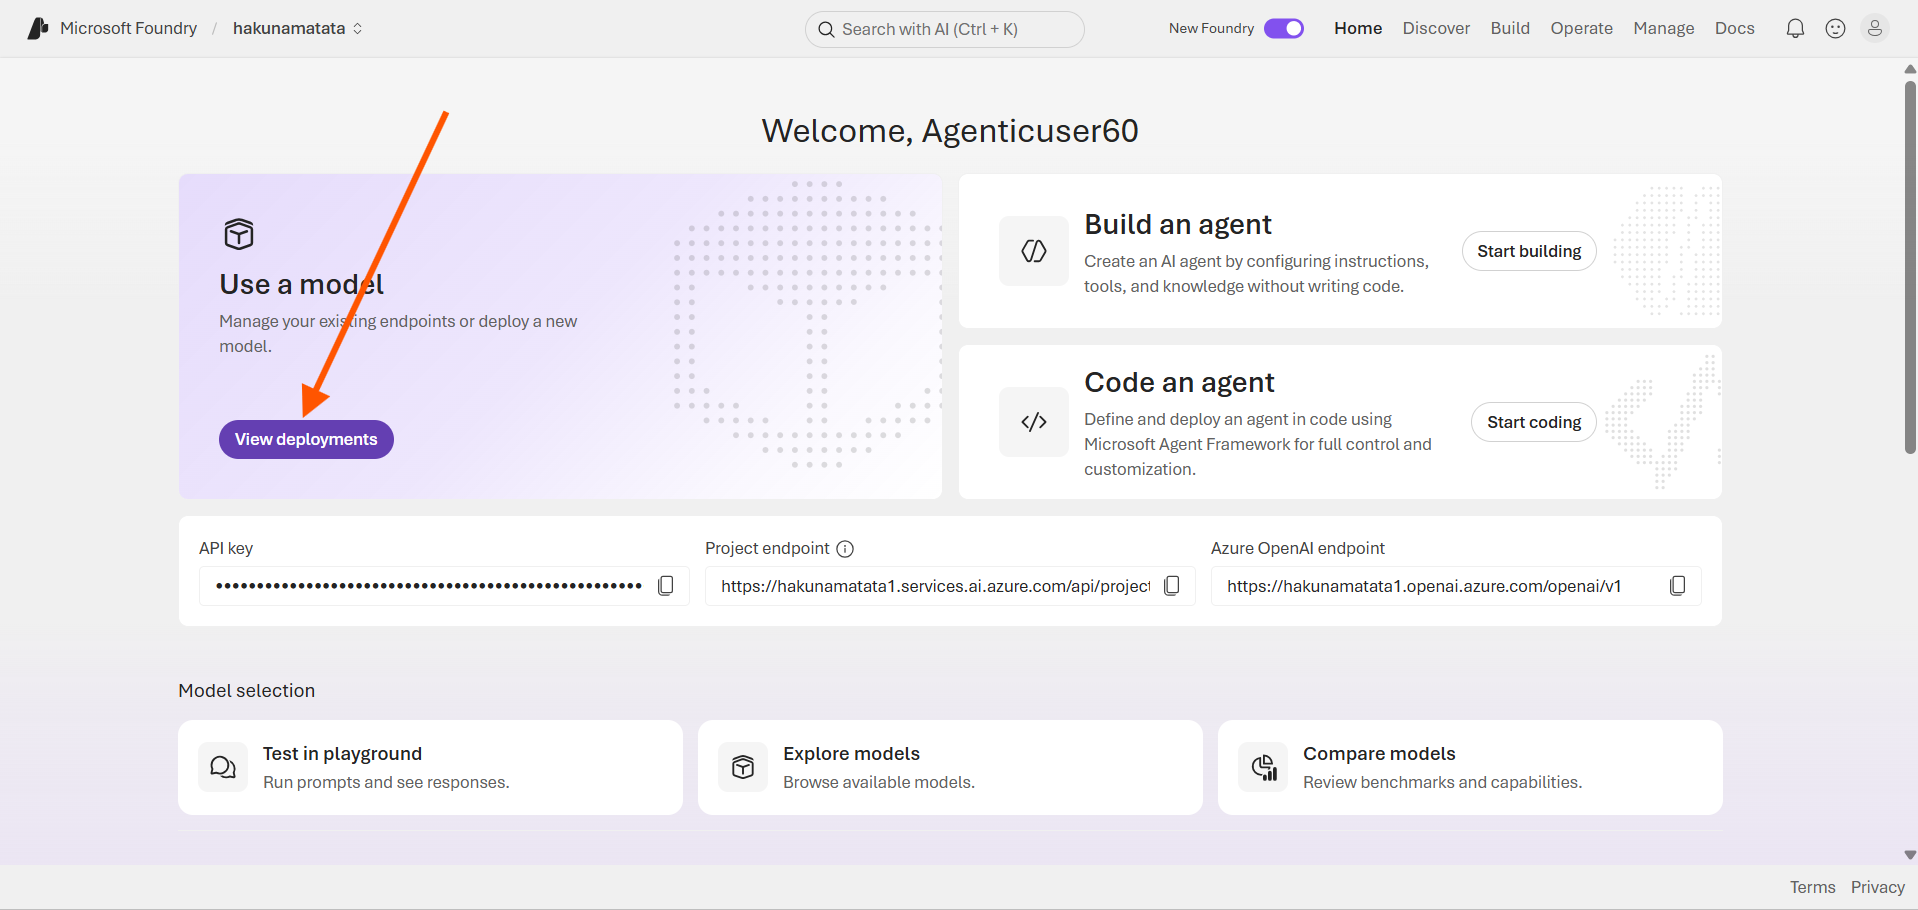

3. Select the deployed **`gpt-5.4-mini`** model.
4. On the **gpt-5.4-mini** deployment page, click **Playground**.
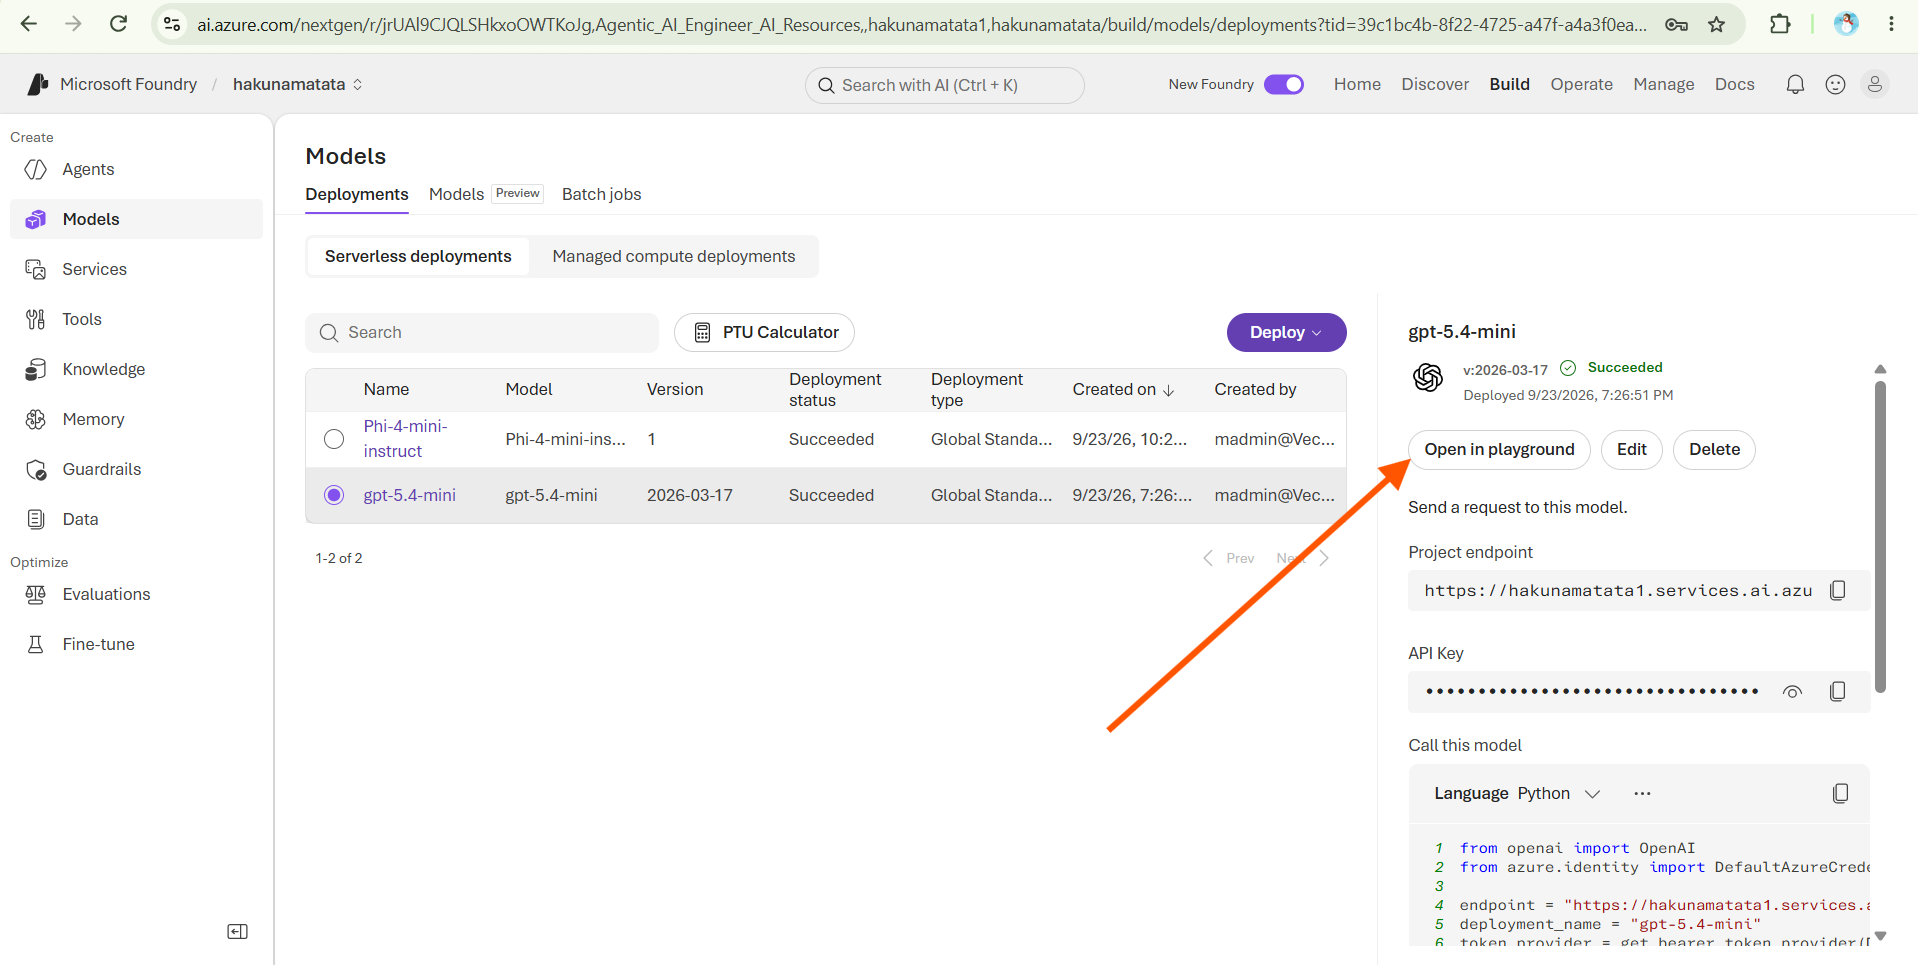

The **gpt-5.4-mini** Playground opens with the following main areas:
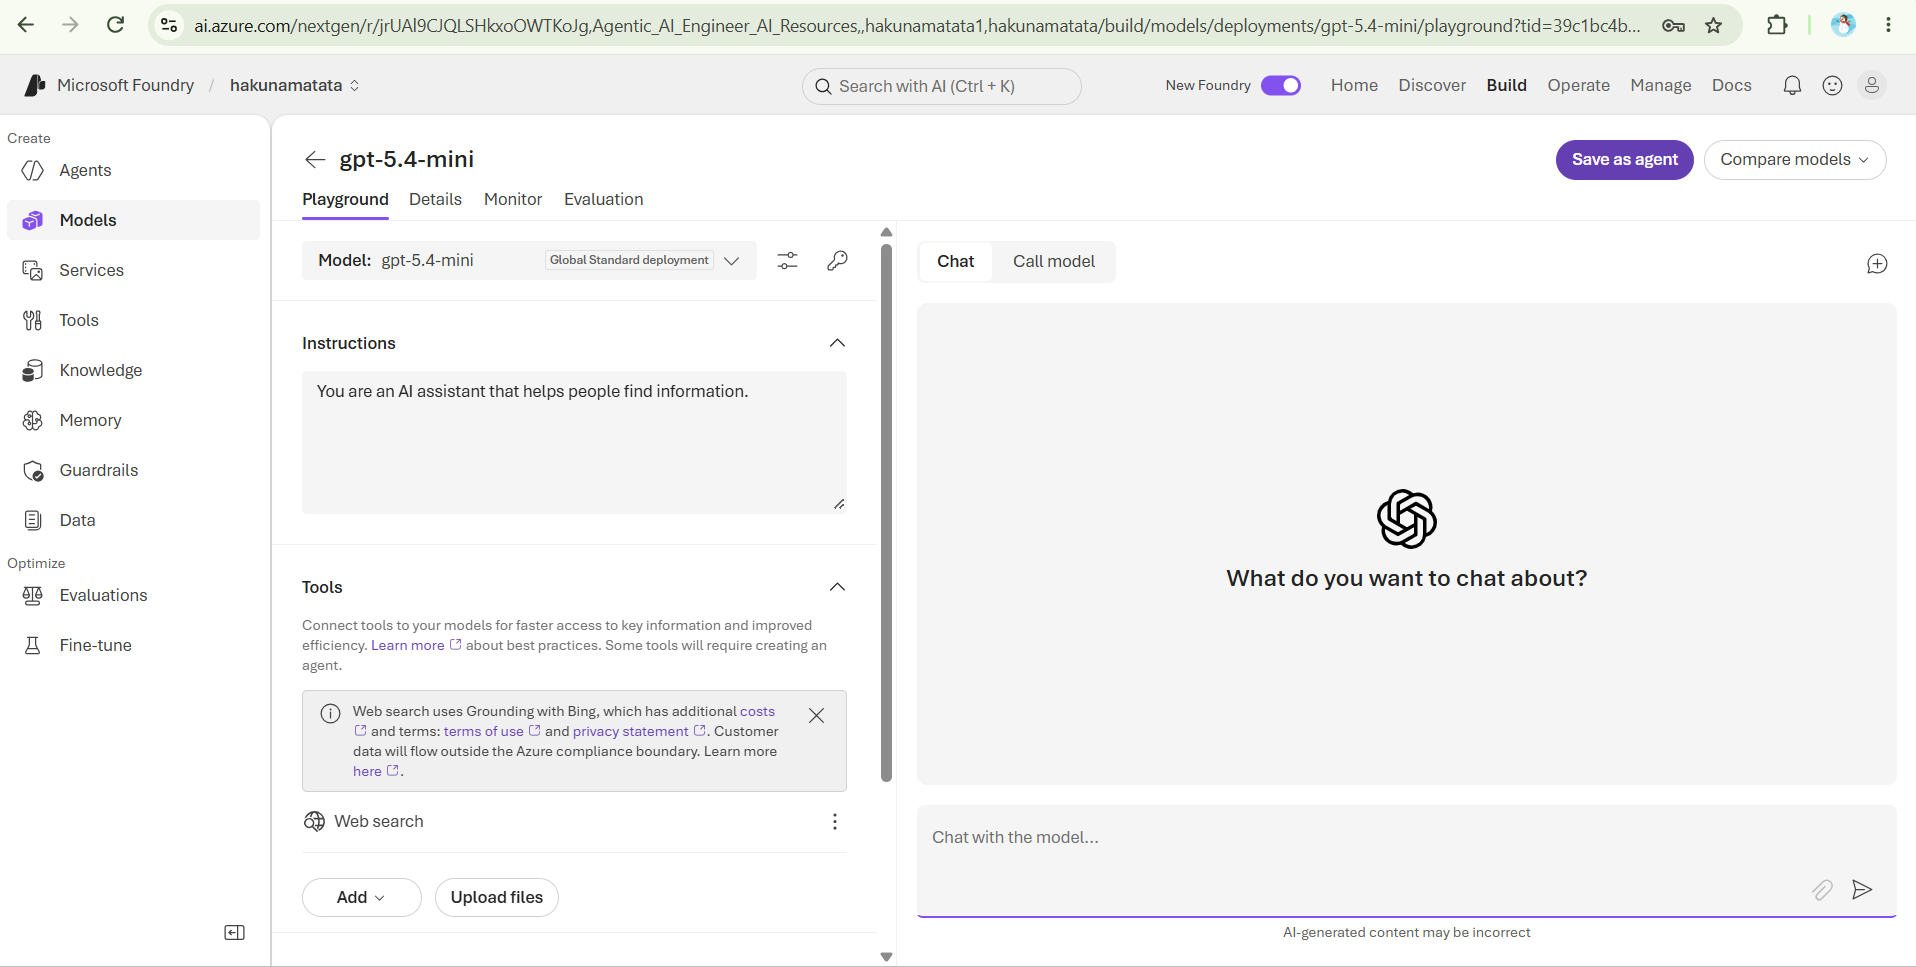


### 1) Model & deployment

* **Model:** `gpt-5.4-mini`
* **Deployment type:** **Global Standard**
* **Save as agent** — Save the current model configuration as an agent.
* **Compare models** — Compare this model with other available models.

### 2) Navigation tabs

At the top of the deployment page:

* **Playground** — Test prompts and interact with the model.
* **Details** — View deployment and model information.
* **Monitor** — View usage, requests, token counts, cost, and performance metrics.
* **Evaluation** — Evaluate model behavior and configure evaluators.

### 3) Instructions

The **Instructions** section lets you provide system-level instructions that guide how **gpt-5.4-mini** responds.

### 4) Tools

The **Tools** section lets you connect additional tools to the model.

For example, **Web search** can provide web-grounded information when enabled.

### 5) Knowledge

Use **Add** to upload files or connect knowledge sources that can provide additional context to the model.

### 6) Memory

The **Memory** section provides memory-related configuration for the model or agent.

### 7) Guardrail

The **Guardrail** section contains safety controls for managing and testing model behavior.

### 8) Chat

The **Chat** section is where you interact directly with **gpt-5.4-mini**.

* **Call model** — Sends your prompt to the deployed model.
* **Chat input** — Enter a prompt such as *“Explain Azure AI Foundry in simple terms.”*
* The response appears directly in the chat area.

**For this lab, use the deployed `gpt-5.4-mini` model in the Chat Playground to test prompts and observe its responses before moving on to the SDK/REST section.**

# Trying out the playground

1. Enter the prompt "Explain Azure AI Foundry in two sentences" and hit Enter
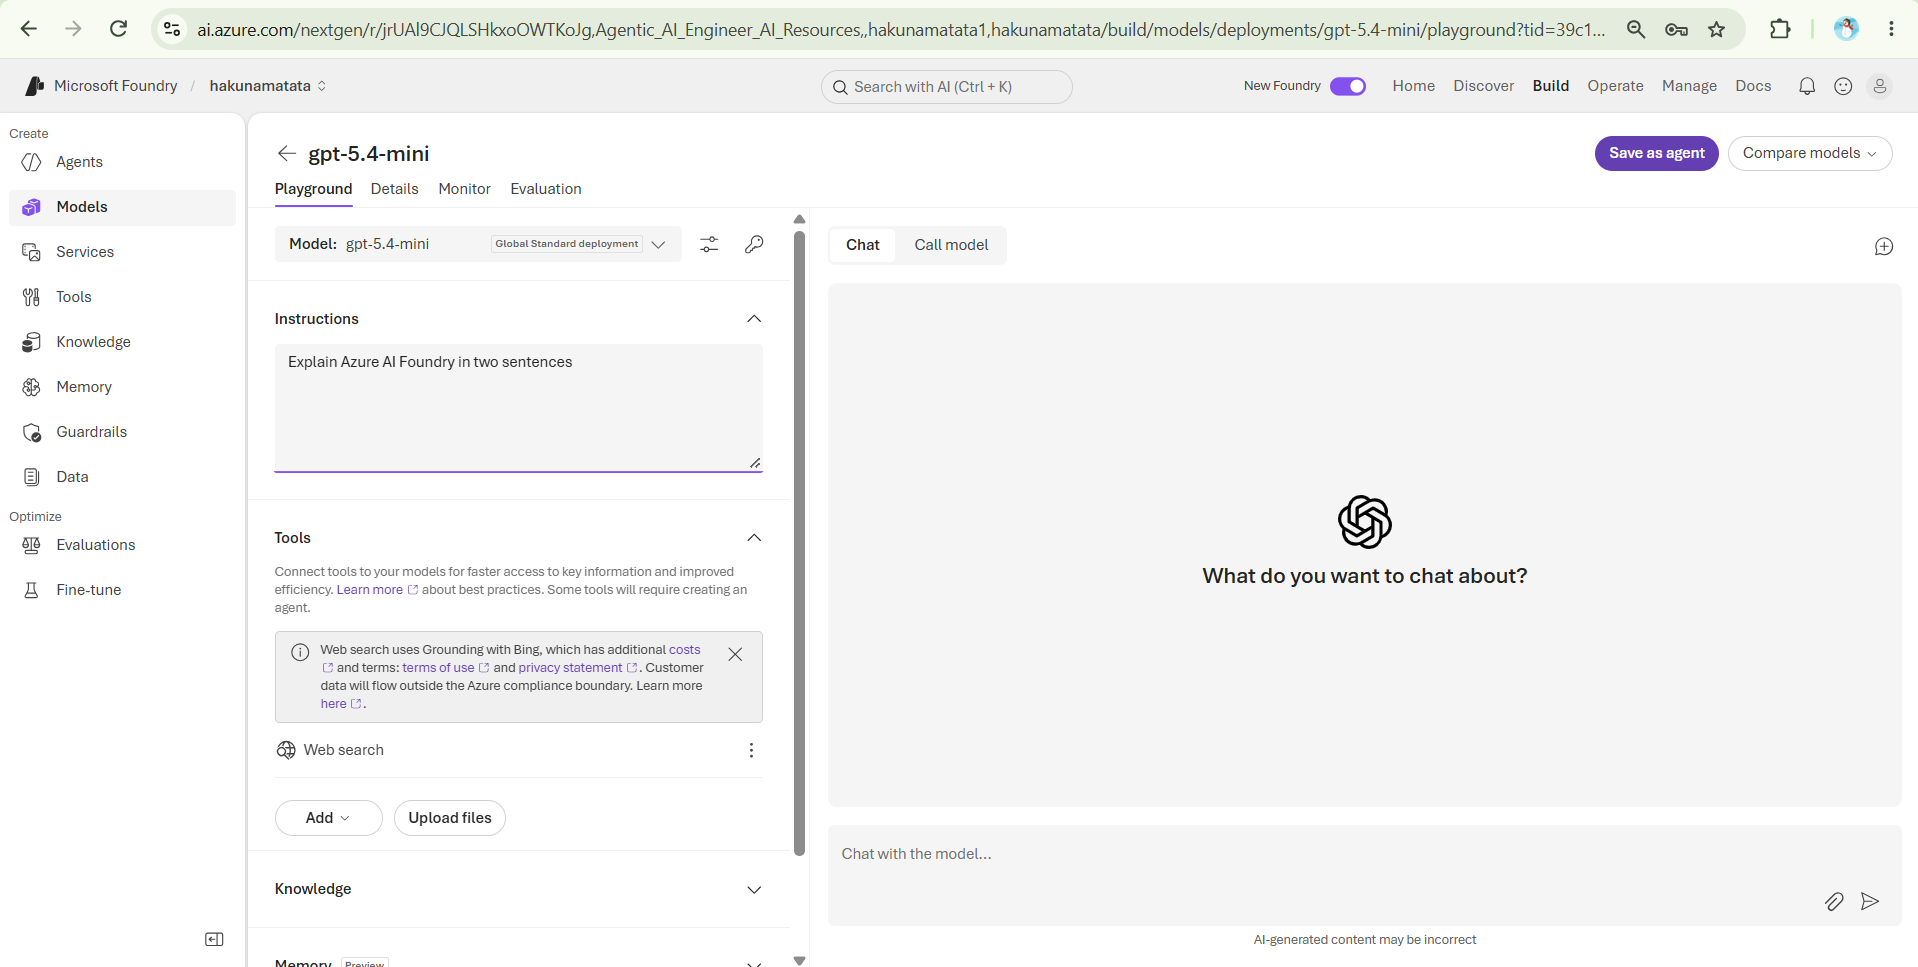


# Testing APIs and optimising model responses

1. From the deployed model page, click the **Details** tab beside **Playground**.

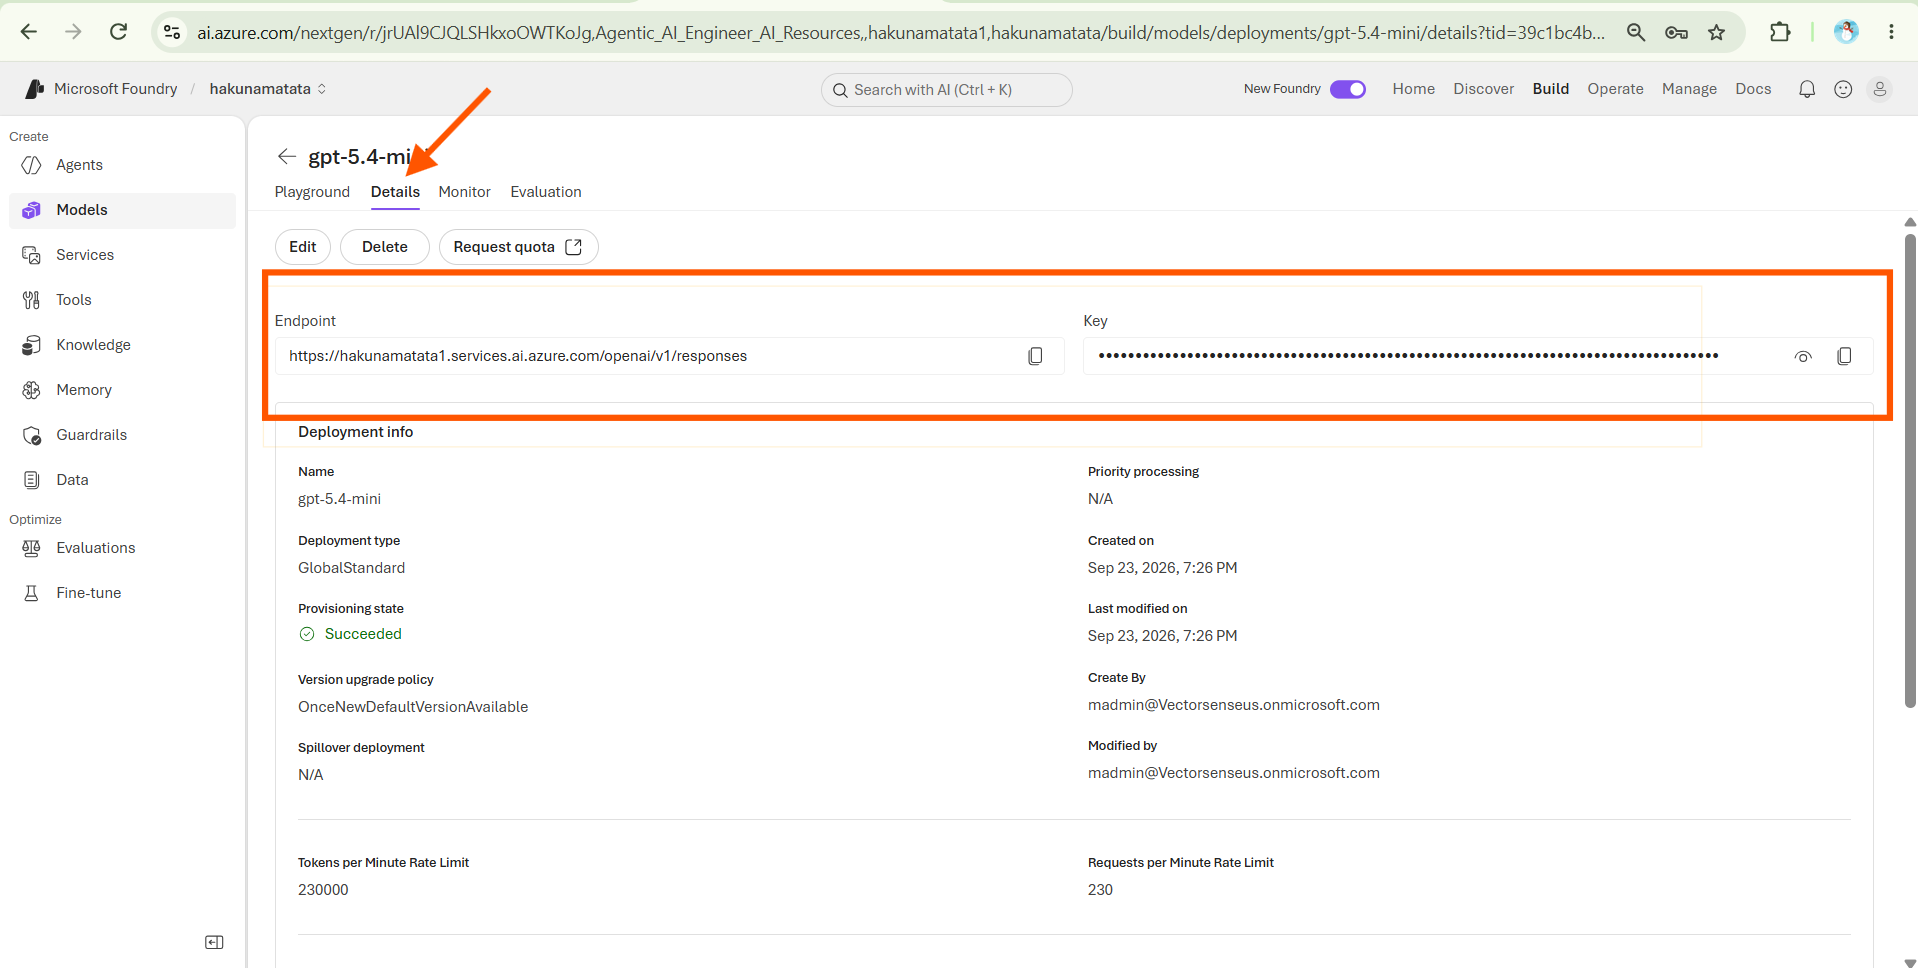


2. Copy the **Endpoint** and **Key**.

3. Save them somewhere safe, such as **Notepad**, so you can use them later whenever the notebook/code requires the endpoint and key.

4. **For the Endpoint**, remove anything that comes after `/v1/`.

   **Example:**

   * Endpoint shown:
     `https://hakunamatata1.services.ai.azure.com/openai/v1/responses`
   * Save/use:
     `https://hakunamatata1.services.ai.azure.com/openai/v1/`

5. Keep the **Key** as it is and save it securely.




# Calling the model

Now, this notebook lets you:

1. Install the Azure AI Inference SDK
2. Configure endpoint credentials
3. Send chat requests (non‑streaming & streaming)
4. Run small prompt‑tuning experiments


**Please ensure the following dependencies are configured properly before proceeding**

- This lab expects you to have the proper settings configured to run a Jupyter notebook (.ipynb) in Visual Studio Code

In case you do not have configuration 1 in place, please hit **Shift + Enter** x 2 and follow the on-screen instructions provided by VS Code for setting up the kernel and environment. Feel free to contact the Lab Support representative for any assistance.

In [ ]:
# Install packages
%pip install --upgrade openai requests

## Configure your endpoint
Fill in the `ENDPOINT`, `API_KEY`, and `DEPLOYMENT` values from your Azure AI Foundry deployment page.

**Ensure to trim the `Target URI` according to the format given below**


In [ ]:
ENDPOINT = "https://hakunamatata1.services.ai.azure.com/openai/v1"
API_KEY = "<REPLACE_WITH_YOUR_API_KEY>"  # Foundry portal → your resource → Keys and Endpoint
DEPLOYMENT = "gpt-5.4-mini"

assert ENDPOINT.startswith("https://"), "Please set a valid ENDPOINT"
assert API_KEY and API_KEY != "<REPLACE_WITH_YOUR_API_KEY>", "Please set your API_KEY"
assert DEPLOYMENT, "Please set your DEPLOYMENT name"

## Initialise a client

In [ ]:
from openai import OpenAI

client = OpenAI(base_url=ENDPOINT, api_key=API_KEY)

## Invoke a basic completion response

In [ ]:
response = client.responses.create(
    model=DEPLOYMENT,
    input=[
        {"role": "system", "content": "You are a concise Azure assistant."},
        {"role": "user",   "content": "In one sentence, define a foundation model."}
    ],
    max_output_tokens=4096,
)
print(response.output_text)

## Streaming example
Set `stream=True` to iterate tokens as they arrive.


In [ ]:
stream = client.responses.create(
    model=DEPLOYMENT,
    input=[
        {"role": "system", "content": "You are a succinct assistant."},
        {"role": "user",   "content": "List 3 prompt tuning levers with a one‑liner each."}
    ],
    max_output_tokens=4096,
    stream=True,
)

for event in stream:
    if event.type == "response.output_text.delta":
        print(event.delta, end="")

# Re-initialising client for rest of the lab

In [ ]:
from openai import OpenAI

client = OpenAI(base_url=ENDPOINT, api_key=API_KEY)

## JSON‑shaped responses
Try to enforce a JSON‑only reply via the system message. If your model supports it, you can also pass a `response_format`. If not, validate JSON client‑side.


In [ ]:
import json

messages_input = [
    {"role": "system", "content": "Return ONLY valid JSON with keys: summary (string), bullets (array)."},
    {"role": "user",   "content": "Summarize what the Chat playground is used for and give 3 bullets."}
]
response = client.responses.create(
    model=DEPLOYMENT,
    input=messages_input,
    text={"format": {"type": "json_object"}},
    max_output_tokens=4096,
)
text = response.output_text
print(text)

try:
    obj = json.loads(text)
    print("\nParsed JSON keys:", list(obj.keys()))
except Exception as e:
    print("\nJSON parse failed:", e)

## Parameter sweep for model optimisation: temperature, max_tokens & top_p
Run a small grid to see how outputs change.


In [ ]:
prompt = "Explain embeddings vs. fine‑tuning for short‑form classification in 3 bullets."
for effort in ["low", "medium", "high"]:
    for mot in [200, 400]:
        res = client.responses.create(
            model=DEPLOYMENT,
            input=[{"role": "user", "content": prompt}],
            reasoning={"effort": effort},
            max_output_tokens=mot,
        )
        print(f"\n--- reasoning_effort={effort} max_output_tokens={mot}")
        print(res.output_text)

## REST via `requests`
You can also call the `/chat/completions` route directly.


In [ ]:
import requests, json

url = f"{ENDPOINT}/responses"
headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
payload = {
    "model": DEPLOYMENT,
    "input": [
        {"role": "system", "content": "You are a concise Azure assistant."},
        {"role": "user",   "content": "Name two cases to prefer a serverless API deployment."}
    ],
    "max_output_tokens": 250
}
resp = requests.post(url, headers=headers, json=payload, timeout=60)
print(resp.status_code)
print(json.dumps(resp.json(), indent=2)[:2000])

# Conclusion & Next Steps

## What you accomplished

- Navigated Azure AI Foundry → explored Model catalog → reviewed model pages.

- Deployed a chat-capable foundation model and verified endpoint details.

- Tested prompts in Chat Playground (system message, safety, parameters).

- Called the model via SDK/REST and ran small tuning experiments (temperature, top-p, max tokens).